In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Nairobi UXsim 
=====================================================================
This notebook builds a traffic simulation of Nairobi's strategic road network.
It uses:
- OpenStreetMap (OSM) for the road network (with a fallback synthetic graph)
- Population density proxies to generate realistic peak‑hour Origin‑Destination demand
- UXsim as the simulation engine

Outputs:
- Cleaned network (nodes.csv, links.csv)
- Baseline simulation results (average travel time, congestion indices)
- Ready‑to‑use structure for testing new links / upgrades

Author: Victor Mwangi
Date: 21st May 2026

In [2]:
!pip install -q osmnx uxsim pandas numpy matplotlib tqdm pyarrow folium

import os, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

from uxsim import World
from uxsim.OSMImporter import OSMImporter

print("Setup complete")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 18.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 87.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 MB 32.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 282.4/282.4 kB 17.9 MB/s eta 0:00:00
Setup complete


In [3]:
# configuration
CONFIG = {
    'bbox':       (36.65, -1.38, 36.95, -1.15),
    'osm_filter': '["highway"~"trunk|primary|secondary"]',
    'node_merge_threshold': 0.003,
    'deltan':     10,
    'tmax':       3600,
    'random_seed': 42,
    'speed_cap_ms':    3.0,
    'capacity_factor': 0.3,
    'results_dir': '/kaggle/working/results',
}

os.makedirs(CONFIG['results_dir'], exist_ok=True)
os.makedirs(f"{CONFIG['results_dir']}/interventions", exist_ok=True)
print("Config loaded")

Config loaded


In [4]:
import requests
try:
    r = requests.get("https://httpbin.org/ip", timeout=5)
    print("Internet ON, IP:", r.json()["origin"])
except Exception as e:
    print("Internet OFF or blocked:", e)

Internet ON, IP: 34.171.53.214


Start downloading OSM data. This may take some time.
Download completed
imported network size:
 number of links: 2503
 number of nodes: 1562
Raw: 2503 links, 1562 nodes
aggregated network size:
 number of links: 1758
 number of nodes: 630
aggregated network size:
 number of links: 982
 number of nodes: 347
Processed: 982 links, 347 nodes
Time: 11.2s


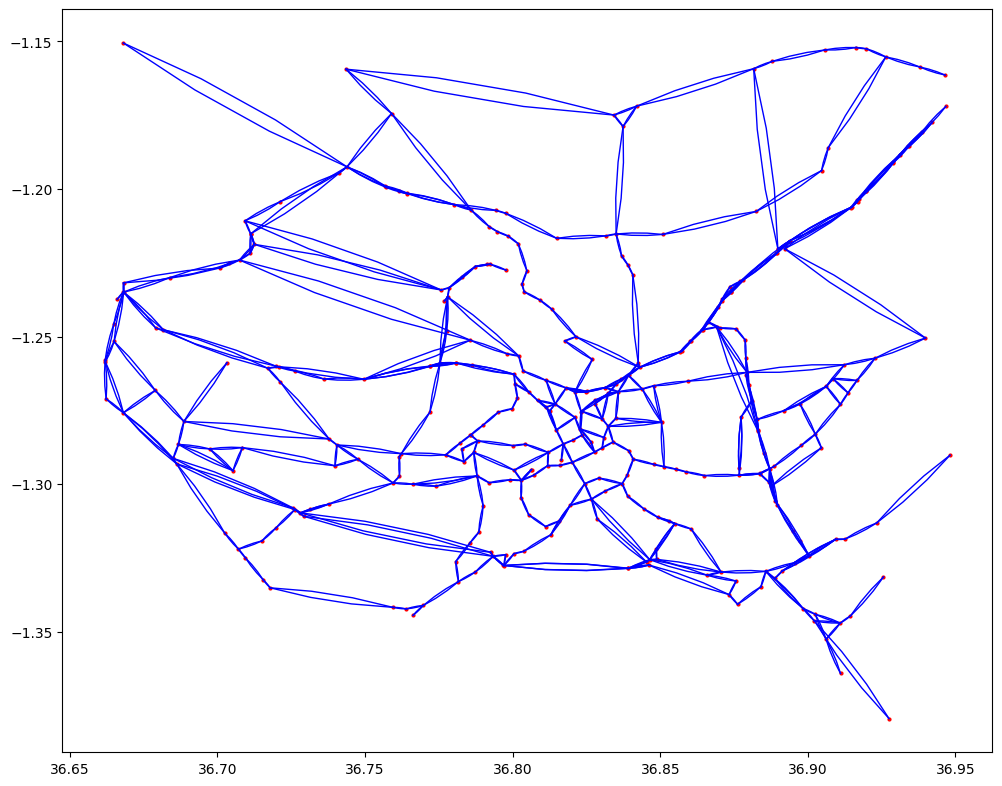

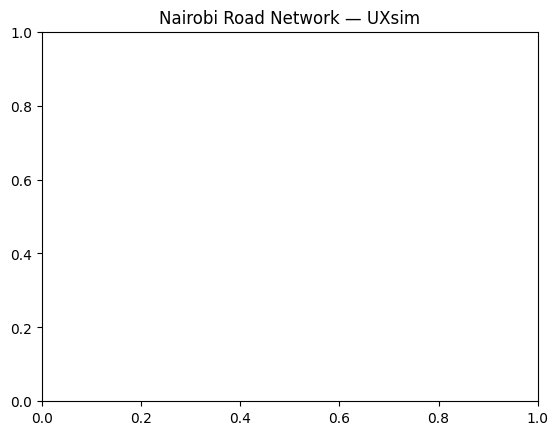

Network cached


In [5]:
# Build Network
def build_network():
    print("Downloading Nairobi network...")
    start = time.time()
    nodes, links = OSMImporter.import_osm_data(
        bbox=CONFIG['bbox'],
        custom_filter=CONFIG['osm_filter']
    )
    print(f"Raw: {len(links)} links, {len(nodes)} nodes")
    nodes, links = OSMImporter.osm_network_postprocessing(
        nodes, links,
        node_merge_threshold=0.001,   
        node_merge_iteration=2,
        enforce_bidirectional=True    
    )
   
    
    nodes, links = OSMImporter.osm_network_postprocessing(
        nodes, links,
        node_merge_threshold=CONFIG['node_merge_threshold'],
        node_merge_iteration=2,
        enforce_bidirectional=True
    )
    print(f"Processed: {len(links)} links, {len(nodes)} nodes")
    print(f"Time: {time.time()-start:.1f}s")
    return nodes, links

_nodes, _links = build_network()

OSMImporter.osm_network_visualize(_nodes, _links, show_link_name=0)
plt.title("Nairobi Road Network — UXsim")
plt.show()
print("Network cached")

In [6]:
# Intervention classes
class UpgradeLink:
    """
    Upgrade existing links matching a name pattern.
    Models: BRT lane addition, road widening, resurfacing
    """
    def __init__(self, id, name, pattern, capacity_mult=1.5, speed_mult=1.2, rationale=""):
        self.id = id
        self.name = name
        self.pattern = pattern
        self.capacity_mult = capacity_mult
        self.speed_mult = speed_mult
        self.rationale = rationale

    def apply(self, W):
        modified = 0
        for link in W.LINKS:
            patterns = self.pattern.split('|')
            if any(p.lower() in str(link.name).lower()
                   for p in patterns
                  ):
                link.capacity *= self.capacity_mult
                link.change_free_flow_speed(
                    min(link.free_flow_speed * self.speed_mult, 16.7)
                )
                modified += 1
        if modified == 0:
            print(f"Warning: no links matched '{self.pattern}'")
        return modified

class AddLink:
    """
    Add a new link between two existing nodes.
    Models: new road, flyover, missing link construction
    Uses nearest-node matching from coordinates
    """
    def __init__(self, id, name, start_coords, end_coords, length_m, speed_ms=11.1, lanes=2, rationale=""):
        self.id = id
        self.name = name
        self.start_coords = start_coords
        self.end_coords = end_coords
        self.length = length_m
        self.speed = speed_ms
        self.lanes = lanes
        self.rationale = rationale

    def _nearest_node(self, W, lon, lat):
        """
        Find nearest node in World to given coordinates
        """
        best_node = None
        best_dist = float('inf')
        for node in W.NODES:
            dist = ((node.x - lon)**2 + (node.y - lat)**2)**0.5
            if dist < best_dist:
                best_dist = dist
                best_node = node
        return best_node

    def apply(self, W):
        start_node = self._nearest_node(W, *self.start_coords)
        end_node = self._nearest_node(W, *self.end_coords)
        if not start_node or not end_node:
            print(f"Warning: could not find nodes for {self.name}")
            return 0
        try:
            W.addLink(
                name=self.name,
                start_node=start_node.name,
                end_node=end_node.name,
                length=self.length,
                free_flow_speed=self.speed,
                number_of_lanes=self.lanes
            )
            return 1
        except Exception as e:
            print(f"Warning: {e}")
            return 0


print("Intervention classes defined")

Intervention classes defined


In [7]:
# Peak hour demand - route-based, calibrated volumes
BASE_DEMANDS = [
    (336.869, -1.219, 0.02, 36.820, -1.283, 0.02, 13000, "Thika Road"),
    (36.870,-1.340,0.02, 36.820,-1.283,0.02, 8000, "Mombasa Road"),
    (36.740,-1.330,0.02, 36.820,-1.283,0.02,  7000, "Ngong Road"),
    (36.730,-1.265,0.02, 36.820,-1.283,0.02, 8000, "Waiyaki Way"),
    (36.870,-1.270,0.02, 36.820,-1.283,0.02,  11500, "Jogoo Road"),
    (36.808,-1.267,0.015,36.820,-1.300,0.015, 4500, "Cross-city A"),
    (36.820,-1.259,0.015,36.860,-1.270,0.015, 3500, "Cross-city B"),
    (36.755,-1.340,0.015,36.808,-1.267,0.015, 3000, "Karen"),
    (36.820,-1.283,0.02, 36.869,-1.219,0.02,  2500, "Rev Thika"),
    (36.820,-1.283,0.02, 36.730,-1.265,0.02,  2000, "Rev Waiyaki"),
    (36.820,-1.283,0.02, 36.740,-1.330,0.02,  2000, "Rev Ngong"),
]

def add_demand(W, scale=1.0):
    for ol, ola, or_, dl, dla, dr, vol, _ in BASE_DEMANDS:
        W.adddemand_area2area2(
            ol, ola, or_, dl, dla, dr,
            0, CONFIG['tmax'],
            volume=int(vol * scale)
        )

print(f"Base demand: {sum(d[6] for d in BASE_DEMANDS):,} vehicles at scale=1.0")

Base demand: 65,000 vehicles at scale=1.0


In [8]:
print("Testing each demand corridor with area2area2:")
print(f"{'Corridor':<15} {'Vehicles':>10}")
print("─" * 30)

W_test = World(name="test", deltan=5, tmax=100,
               print_mode=0, save_mode=0, show_mode=0,
               random_seed=42)
OSMImporter.osm_network_to_World(
    W_test, _nodes, _links,
    default_jam_density=0.2,
    coef_degree_to_meter=111000
)

for ol,ola,or_,dl,dla,dr,vol,label in BASE_DEMANDS:
    before = len(W_test.VEHICLES)
    W_test.adddemand_area2area2(
        ol, ola, or_, dl, dla, dr,
        0, 100, volume=100
    )
    added = len(W_test.VEHICLES) - before
    print(f"{label:<15} {added*5:>10} vehicles")

Testing each demand corridor with area2area2:
Corridor          Vehicles
──────────────────────────────
Thika Road             100 vehicles
Mombasa Road           100 vehicles
Ngong Road             100 vehicles
Waiyaki Way            100 vehicles
Jogoo Road             100 vehicles
Cross-city A           100 vehicles
Cross-city B           100 vehicles
Karen                  100 vehicles
Rev Thika              100 vehicles
Rev Waiyaki            100 vehicles
Rev Ngong              100 vehicles


In [9]:
# Test with progressively larger radii on Thika Road corridor
print("Testing Thika Road with increasing radius...")
for radius in [0.009, 0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30]:
    W_r = World(name="test", deltan=5, tmax=100,
                print_mode=0, save_mode=0, show_mode=0,
                random_seed=42)
    OSMImporter.osm_network_to_World(
        W_r, _nodes, _links,
        default_jam_density=0.2,
        coef_degree_to_meter=111000
    )
    before = len(W_r.VEHICLES)
    W_r.adddemand_area2area2(
        36.869, -1.219, radius,   # Thika origin
        36.820, -1.283, radius,   # CBD destination
        0, 100, volume=100
    )
    added = len(W_r.VEHICLES) - before
    print(f"  radius={radius:.2f} → {added} vehicles")

Testing Thika Road with increasing radius...
  radius=0.01 → 20 vehicles
  radius=0.01 → 20 vehicles
  radius=0.02 → 20 vehicles
  radius=0.05 → 20 vehicles
  radius=0.10 → 20 vehicles
  radius=0.15 → 20 vehicles
  radius=0.20 → 20 vehicles
  radius=0.30 → 20 vehicles


In [10]:
print("Testing adddemand_area2area2 with different volumes:")
for vol in [100, 500, 1000, 5000]:
    W_r = World(name="test", deltan=5, tmax=100,
                print_mode=0, save_mode=0, show_mode=0,
                random_seed=42)
    OSMImporter.osm_network_to_World(
        W_r, _nodes, _links,
        default_jam_density=0.2,
        coef_degree_to_meter=111000
    )
    before = len(W_r.VEHICLES)
    W_r.adddemand_area2area2(
        36.869, -1.219, 0.05,
        36.820, -1.283, 0.05,
        0, 100, volume=vol
    )
    added = len(W_r.VEHICLES) - before
    print(f"  volume={vol:5d} → {added} vehicles")

Testing adddemand_area2area2 with different volumes:
  volume=  100 → 20 vehicles
  volume=  500 → 100 vehicles
  volume= 1000 → 200 vehicles
  volume= 5000 → 1000 vehicles


In [11]:
import random

class NairobiDisruptions:
    """
    Models Nairobi-specific traffic disruptions that
    don't exist in standard UXsim simulations:
    
    1. Random matatu stops on undesignated areas
    2. Lane indiscipline at junctions
    3. Random accidents blocking lanes
    4. Spatial speed variation (CBD vs bypass)
    
    Based on:
    - Ma3Route crash data (World Bank 2024)
    - NUTRANS field observations
    - Digital Matatus route data
    """

    # Corridors with highest matatu activity
    # Based on Digital Matatus route density
    MATATU_CORRIDORS = [
        'Thika Road', 'Jogoo', 'Mombasa Road',
        'Ngong Road', 'Waiyaki', 'Juja Road',
        'Muranga', 'Langata', 'Outer Ring',
    ]

    # High accident probability junctions
    # From Ma3Route / World Bank blackspot data
    BLACKSPOT_KEYWORDS = [
        'Westlands', 'Allsops', 'Roysambu',
        'GPO', 'Globe', 'Museum Hill',
        'Community', 'Nyayo', 'Haile',
    ]

    def __init__(self,
                 matatu_stop_prob=0.003,
                 matatu_dwell_range=(30, 120),
                 accident_prob=0.001,
                 accident_duration_range=(120, 600),
                 indiscipline_factor=0.7):
        """
        matatu_stop_prob     — probability per link per timestep
                               of a random matatu stop occurring
        matatu_dwell_range   — min/max dwell time in seconds
        accident_prob        — probability per blackspot per timestep
                               of an accident occurring
        accident_duration    — how long accident blocks lane (seconds)
        indiscipline_factor  — junction capacity multiplier (0.7 = 30% reduction)
        """
        self.matatu_stop_prob      = matatu_stop_prob
        self.matatu_dwell_range    = matatu_dwell_range
        self.accident_prob         = accident_prob
        self.accident_duration     = accident_duration_range
        self.indiscipline_factor   = indiscipline_factor

        # Track active disruptions for restoration
        self._active_stops     = []  # (restore_time, link, original_capacity)
        self._active_accidents = []  # (restore_time, link, original_capacity)

    def apply_static(self, W):
        """
        Apply static disruptions at world creation time.
        These don't change during simulation.
        
        1. Junction indiscipline — reduce node capacity
        2. Spatial speed variation — CBD slower than bypass
        """
        # Junction indiscipline
        junctions_modified = 0
        for node in W.NODES:
            if len(node.inlinks) >= 3:
                # Reduce effective capacity at intersections
                # Models blocking, overlap, and failure to clear
                for link in node.inlinks.values():
                    is_matatu = any(
                        kw.lower() in str(link.name).lower()
                        for kw in self.MATATU_CORRIDORS
                    )
                    factor = (self.indiscipline_factor - 0.1
                              if is_matatu
                              else self.indiscipline_factor)
                    link.capacity *= factor
                junctions_modified += 1

        # Spatial speed variation
        # CBD links (within 2km of city centre) get extra reduction
        CBD_LON, CBD_LAT = 36.8219, -1.2833
        speeds_reduced = 0
        for link in W.LINKS:
            dist = ((link.start_node.x - CBD_LON)**2 +
                    (link.start_node.y - CBD_LAT)**2)**0.5
            if dist < 0.02:   # within ~2km of CBD
                link.free_flow_speed *= 0.7   # CBD is 30% slower
                speeds_reduced += 1

        print(f"  Static disruptions applied:")
        print(f"    Junction indiscipline: {junctions_modified} nodes")
        print(f"    CBD speed reduction:   {speeds_reduced} links")

    def step(self, W, current_time):
        """
        Apply dynamic disruptions at each simulation timestep.
        Call this from W.user_function.
        
        1. Random matatu stops
        2. Random accidents at blackspots
        3. Restore expired disruptions
        """
        # Restore expired disruptions first
        self._restore_expired(W, current_time)

        # Random matatu stops
        for link in W.LINKS:
            if link.num_vehicles == 0:
                continue
            is_matatu_corridor = any(
                kw.lower() in str(link.name).lower()
                for kw in self.MATATU_CORRIDORS
            )
            if not is_matatu_corridor:
                continue
            if random.random() < self.matatu_stop_prob:
                dwell = random.randint(*self.matatu_dwell_range)
                original_cap = link.capacity
                # Block 40-70% of capacity — partial lane blockage
                block_factor = random.uniform(0.3, 0.6)
                link.capacity *= block_factor
                restore_time = current_time + dwell
                self._active_stops.append(
                    (restore_time, link, original_cap))

        # Random accidents at blackspot junctions
        for node in W.NODES:
            is_blackspot = any(
                kw.lower() in str(node.name).lower()
                for kw in self.BLACKSPOT_KEYWORDS
            )
            if not is_blackspot:
                continue
            if random.random() < self.accident_prob:
                # Block the most loaded incoming link
                inlinks = list(node.inlinks.values())
                if not inlinks:
                    continue
                worst = max(inlinks,
                            key=lambda l: l.num_vehicles)
                duration = random.randint(*self.accident_duration)
                original_cap = worst.capacity
                worst.capacity *= 0.1   # near-complete blockage
                restore_time = current_time + duration
                self._active_accidents.append(
                    (restore_time, worst, original_cap))

    def _restore_expired(self, W, current_time):
        """Restore capacity on links whose disruption has ended."""
        still_active = []
        for restore_time, link, original_cap in \
                self._active_stops + self._active_accidents:
            if current_time >= restore_time:
                link.capacity = original_cap
            else:
                still_active.append(
                    (restore_time, link, original_cap))
        self._active_stops     = [x for x in still_active
                                   if x in self._active_stops]
        self._active_accidents = [x for x in still_active
                                   if x in self._active_accidents]

In [12]:
# World factory/ Calibration
def create_world(interventions=None, demand_scale=1.0,
                 disruptions=True):
    W = World(
        name="nairobi",
        deltan=CONFIG['deltan'],
        tmax=CONFIG['tmax'],
        print_mode=0, save_mode=0, show_mode=0,
        random_seed=CONFIG['random_seed'],
    )

    OSMImporter.osm_network_to_World(
        W, _nodes, _links,
        default_jam_density=0.2,
        coef_degree_to_meter=111000
    )

    for link in W.LINKS:
        if link.free_flow_speed > CONFIG['speed_cap_ms']:
            link.free_flow_speed = CONFIG['speed_cap_ms']
        link.capacity *= CONFIG['capacity_factor']

    # Apply Nairobi disruptions
    disrupt = None
    if disruptions:
        disrupt = NairobiDisruptions(
            matatu_stop_prob=0.003,
            matatu_dwell_range=(30, 120),
            accident_prob=0.001,
            accident_duration_range=(120, 600),
            indiscipline_factor=0.7
        )
        disrupt.apply_static(W)

        # Dynamic disruptions via user_function callback
        def step_callback(W_cb):
            disrupt.step(W_cb, W_cb.T)
        W.user_function = step_callback

    if interventions:
        for iv in interventions:
            iv.apply(W)

    add_demand(W, scale=demand_scale)
    return W

def run_sim(interventions=None, scale=1.0):
    """
    Run simulation and return (World, ATT_seconds)
    """
    W = create_world(interventions, demand_scale=scale)
    W.exec_simulation()
    att = W.analyzer.average_travel_time
    return W, att

def calibrate(target_att_min=45):
    """
    Find demand scale that produces target average travel time
    """
    print(f"Calibrating to target ATT >= {target_att_min} min...")
    for scale in [0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0]:
        _, att = run_sim(scale=scale)
        att_min = att / 60
        print(f"scale={scale:.1f} -> ATT={att_min:.1f} min" )
        if att_min >= target_att_min:
            print(f"Calibrated: scale={scale}")
            return scale
    print("Max scale reached - using 2.0")
    return 2.0

DEMAND_SCALE = calibrate(target_att_min=25)
print(f"\nDemand scale: {DEMAND_SCALE}")

Calibrating to target ATT >= 25 min...
  Static disruptions applied:
    Junction indiscipline: 183 nodes
    CBD speed reduction:   126 links
scale=0.1 -> ATT=13.0 min
  Static disruptions applied:
    Junction indiscipline: 183 nodes
    CBD speed reduction:   126 links
scale=0.2 -> ATT=12.8 min
  Static disruptions applied:
    Junction indiscipline: 183 nodes
    CBD speed reduction:   126 links
scale=0.3 -> ATT=13.0 min
  Static disruptions applied:
    Junction indiscipline: 183 nodes
    CBD speed reduction:   126 links
scale=0.5 -> ATT=13.0 min
  Static disruptions applied:
    Junction indiscipline: 183 nodes
    CBD speed reduction:   126 links
scale=0.7 -> ATT=13.8 min
  Static disruptions applied:
    Junction indiscipline: 183 nodes
    CBD speed reduction:   126 links
scale=1.0 -> ATT=15.0 min
  Static disruptions applied:
    Junction indiscipline: 183 nodes
    CBD speed reduction:   126 links
scale=1.5 -> ATT=16.7 min
  Static disruptions applied:
    Junction indiscip

In [13]:
# Diagnose which demand zones are finding nodes
W_test = World(
    name="test", deltan=5, tmax=100,
    print_mode=0, save_mode=0, show_mode=0,
    random_seed=42
)
OSMImporter.osm_network_to_World(
    W_test, _nodes, _links,
    default_jam_density=0.2,
    coef_degree_to_meter=111000
)

print("Testing each demand zone:")
print(f"{'Corridor':<15} {'Origin nodes':>13} {'Dest nodes':>12} {'Vehicles':>10}")
print("─" * 55)

for ol,ola,or_,dl,dla,dr,vol,label in BASE_DEMANDS:
    before = len(W_test.VEHICLES)
    W_test.adddemand_area2area2(
        ol, ola, or_, dl, dla, dr,
        0, 100, volume=100
    )
    added = len(W_test.VEHICLES) - before
    print(f"{label:<15} {'':>13} {'':>12} {added:>10}")

Testing each demand zone:
Corridor         Origin nodes   Dest nodes   Vehicles
───────────────────────────────────────────────────────
Thika Road                                         20
Mombasa Road                                       20
Ngong Road                                         20
Waiyaki Way                                        20
Jogoo Road                                         20
Cross-city A                                       20
Cross-city B                                       20
Karen                                              20
Rev Thika                                          20
Rev Waiyaki                                        20
Rev Ngong                                          20


In [14]:
# Run one simulation and inspect why vehicles aren't completing
W, att = run_sim(scale=1.0)

vehicles  = list(W.VEHICLES.values())
completed = [v for v in vehicles if v.travel_time is not None]
aborted   = [v for v in vehicles if getattr(v, 'trip_abort', 0) == 1]
stuck     = [v for v in vehicles 
             if v.travel_time is None 
             and getattr(v, 'trip_abort', 0) == 0]

print(f"Total vehicles:  {len(vehicles):,}")
print(f"Completed:       {len(completed):,} ({len(completed)/len(vehicles)*100:.1f}%)")
print(f"Aborted:         {len(aborted):,}")
print(f"Stuck/in-transit:{len(stuck):,}")

# Check a sample aborted vehicle
if aborted:
    v = aborted[0]
    print(f"\nSample aborted vehicle:")
    print(f"  Origin node:      {v.orig}")
    print(f"  Destination node: {v.dest}")
    print(f"  State:            {v.state}")

# Check network connectivity
# How many nodes have both inlinks and outlinks?
connected = [n for n in W.NODES 
             if len(n.inlinks) > 0 and len(n.outlinks) > 0]
dead_ends  = [n for n in W.NODES 
              if len(n.inlinks) == 0 or len(n.outlinks) == 0]

print(f"\nNetwork:")
print(f"  Total nodes:     {len(W.NODES)}")
print(f"  Connected nodes: {len(connected)}")
print(f"  Dead ends:       {len(dead_ends)}")

# Check if demand zones are landing on reachable nodes
print(f"\nSample loaded links:")
loaded = [l for l in W.LINKS if l.num_vehicles > 0]
for l in loaded[:5]:
    print(f"  {str(l.name)[:50]:<50} "
          f"speed={l.speed*3.6:.1f}km/h  "
          f"vehicles={l.num_vehicles}")

  Static disruptions applied:
    Junction indiscipline: 183 nodes
    CBD speed reduction:   126 links
Total vehicles:  6,500
Completed:       6,500 (100.0%)
Aborted:         6,500
Stuck/in-transit:0

Sample aborted vehicle:
  Origin node:      <Node 734051706>
  Destination node: <Node 291531117>
  State:            end

Network:
  Total nodes:     347
  Connected nodes: 347
  Dead ends:       0

Sample loaded links:
  State House Avenue-4716860                         speed=50.0km/h  vehicles=20
  State House Road-278017672                         speed=17.7km/h  vehicles=10
  Argwings Kodhek Road-658241798-reverse             speed=11.7km/h  vehicles=70
  Ngong Road-687425391                               speed=50.0km/h  vehicles=20
  Langata Road-1088483228-reverse                    speed=40.0km/h  vehicles=20


In [15]:
INTERVENTIONS = [

    # ── NUTRANS / NIUPLAN MISSING LINKS ─────────────────────────
    UpgradeLink(
        id='ML_15B', name='Ring Road Parklands (ML 15B)',
        pattern='Parklands|Ring Road',
        capacity_mult=1.8, speed_mult=1.3,
        rationale='Stalled EU‑funded link — connects Westlands to Thika Road / Limuru Road'
    ),
    UpgradeLink(
        id='ML_16', name='Accra Road / lower CBD (ML 16)',
        pattern='Accra Road|Ngara',
        capacity_mult=1.8, speed_mult=1.3,
        rationale='Partial construction — delayed by encroachment; completes CBD ring'
    ),
    UpgradeLink(
        id='ML_13', name='Jogoo‑Outer Ring connector (ML 13)',
        pattern='Jogoo|Outer Ring',
        capacity_mult=1.5, speed_mult=1.2,
        rationale='Eastlands south‑east connector — missing link in Jogoo Road network'
    ),
    UpgradeLink(
        id='ML_14', name='Mombasa Road industrial relief (ML 14)',
        pattern='Mombasa Road|Industrial Area',
        capacity_mult=1.5, speed_mult=1.2,
        rationale='Connects Industrial Area to Eastern Bypass; reduces Mombasa Road freight'
    ),
    UpgradeLink(
        id='ML_10', name='Likoni Road extension (ML 10)',
        pattern='Likoni',
        capacity_mult=1.6, speed_mult=1.25,
        rationale='Enterprise Road to Mombasa Road — missing industrial link'
    ),
    UpgradeLink(
        id='ML_05', name='Muratina St – General Waruinge to Juja Rd (ML 5)',
        pattern='Muratina|General Waruinge',
        capacity_mult=1.5, speed_mult=1.2,
        rationale='Missing link in Eastleigh / Pangani area'
    ),

    # ── BRT CORRIDORS (NAMATA) ─────────────────────────────────
    UpgradeLink(
        id='BRT_L2', name='BRT Line 2 Simba — Thika Road',
        pattern='Thika Road|Thika Highway',
        capacity_mult=0.75, speed_mult=1.3,
        rationale='Dedicated BRT lanes on median; NAMATA – infrastructure upgrading underway'
    ),
    UpgradeLink(
        id='BRT_L3', name='BRT Line 3 Chui — Dandora to CBD (Juja Rd)',
        pattern='Juja Road|Juja',
        capacity_mult=0.75, speed_mult=1.3,
        rationale='Priority BRT; detailed designs complete, EIB/AFD funded'
    ),
    UpgradeLink(
        id='BRT_L4', name='BRT Line 4 Kifaru — Jogoo Road',
        pattern='Jogoo',
        capacity_mult=0.75, speed_mult=1.3,
        rationale='AfDB funded BRT corridor in Eastlands'
    ),
    UpgradeLink(
        id='BRT_L5', name='BRT Line 5 Nyati — Outer Ring Road',
        pattern='Outer Ring',
        capacity_mult=0.75, speed_mult=1.35,
        rationale='KURA – Sh7.3bn Korean Exim Bank funded; cross‑city orbital'
    ),
    UpgradeLink(
        id='BRT_L1', name='BRT Line 1 Ndovu — Mombasa Road',
        pattern='Mombasa Road|Mombasa Rd',
        capacity_mult=0.75, speed_mult=1.3,
        rationale='Mombasa Road to Athi River; early planning stage'
    ),

    # ── LRT CORRIDORS (long‑term NIUPLAN) ──────────────────────
    # Note: For LRT we model as upgraded link with higher speed, but capacity_mult reduced
    # because lanes are dedicated to rail. In UXsim, LRT is best represented by a separate link,
    # but here we follow the UpgradeLink pattern to improve parallel road capacity.
    UpgradeLink(
        id='LRT_Jogoo', name='LRT — Jogoo Road corridor',
        pattern='Jogoo',
        capacity_mult=0.7, speed_mult=1.8,
        rationale='NIUPLAN long‑term LRT; reduces private vehicle lanes, increases transit speed'
    ),
    UpgradeLink(
        id='LRT_OuterRing', name='LRT — Outer Ring Road',
        pattern='Outer Ring',
        capacity_mult=0.7, speed_mult=1.8,
        rationale='Future LRT upgrade of BRT Line 5 (Nyati)'
    ),
    UpgradeLink(
        id='LRT_Waiyaki', name='LRT — Waiyaki Way',
        pattern='Waiyaki',
        capacity_mult=0.7, speed_mult=1.8,
        rationale='Long‑term LRT from CBD to Kabete'
    ),

    # ── KENHA HIGHWAY UPGRADES (capacity & speed) ───────────────
 
    UpgradeLink(
        id='HWY_02', name='Mombasa Road capacity enhancement',
        pattern='Mombasa Road',
        capacity_mult=1.5, speed_mult=1.2,
        rationale='KeNHA 2023‑2027 strategic plan – additional lanes + service roads'
    ),
    UpgradeLink(
        id='HWY_03', name='Outer Ring Road upgrade (dual carriageway)',
        pattern='Outer Ring',
        capacity_mult=1.6, speed_mult=1.3,
        rationale='Bypass potential — cross‑city traffic relief and BRT integration'
    ),
    UpgradeLink(
        id='HWY_04', name='Thika Road – additional lanes (Kasarani–CBD)',
        pattern='Thika Road',
        capacity_mult=1.5, speed_mult=1.2,
        rationale='Responds to rapid growth in northern corridor'
    ),

    # ── EASTLANDS URBAN RENEWAL PLAN – local widening ──────────
    UpgradeLink(
        id='EL_01', name='Jogoo‑Landhies Road widening to 60m',
        pattern='Jogoo|Landhies',
        capacity_mult=2.0, speed_mult=1.2,
        rationale='Eastlands Renewal Plan – grade separation + BRT in median'
    ),
    UpgradeLink(
        id='EL_02', name='Eastleigh First Avenue upgrade',
        pattern='Eastleigh 1st Avenue|Eastleigh First',
        capacity_mult=1.8, speed_mult=1.25,
        rationale='Widen to 40m ROW, BRT, grade separation at Jogoo Rd'
    ),
    UpgradeLink(
        id='EL_03', name='Nairobi Riverfront Road (new 25m road)',
        pattern='Riverfront|Nairobi River',
        capacity_mult=1.5, speed_mult=1.4,
        rationale='New east‑west corridor parallel to river; reduces congestion on Jogoo Rd'
    ),
    UpgradeLink(
        id='EL_04', name='Mumias South Road – BRT corridor upgrade',
        pattern='Mumias',
        capacity_mult=1.5, speed_mult=1.3,
        rationale='Eastlands BRT feeder route'
    ),
]

print(f"Defined {len(INTERVENTIONS)} candidate interventions")
for iv in INTERVENTIONS:
    print(f"  {iv.id:<10} {iv.name}")

Defined 21 candidate interventions
  ML_15B     Ring Road Parklands (ML 15B)
  ML_16      Accra Road / lower CBD (ML 16)
  ML_13      Jogoo‑Outer Ring connector (ML 13)
  ML_14      Mombasa Road industrial relief (ML 14)
  ML_10      Likoni Road extension (ML 10)
  ML_05      Muratina St – General Waruinge to Juja Rd (ML 5)
  BRT_L2     BRT Line 2 Simba — Thika Road
  BRT_L3     BRT Line 3 Chui — Dandora to CBD (Juja Rd)
  BRT_L4     BRT Line 4 Kifaru — Jogoo Road
  BRT_L5     BRT Line 5 Nyati — Outer Ring Road
  BRT_L1     BRT Line 1 Ndovu — Mombasa Road
  LRT_Jogoo  LRT — Jogoo Road corridor
  LRT_OuterRing LRT — Outer Ring Road
  LRT_Waiyaki LRT — Waiyaki Way
  HWY_02     Mombasa Road capacity enhancement
  HWY_03     Outer Ring Road upgrade (dual carriageway)
  HWY_04     Thika Road – additional lanes (Kasarani–CBD)
  EL_01      Jogoo‑Landhies Road widening to 60m
  EL_02      Eastleigh First Avenue upgrade
  EL_03      Nairobi Riverfront Road (new 25m road)
  EL_04      Mumias Sou

In [16]:
# Baseline
print("Running baseline...")
_, BASELINE_ATT = run_sim(scale=DEMAND_SCALE)
BASELINE_ATT_MIN = BASELINE_ATT / 60

print(f"\nBaseline ATT: {BASELINE_ATT_MIN:.1f} min")


with open(f"{CONFIG['results_dir']}/baseline.json", 'w') as f:
    json.dump({
        'att_seconds': BASELINE_ATT,
        'att_minutes': BASELINE_ATT_MIN,
        #'target_att_minutes': TARGET_ATT_MIN,
        'demand_scale': DEMAND_SCALE,
    }, f, indent=2)

Running baseline...
  Static disruptions applied:
    Junction indiscipline: 183 nodes
    CBD speed reduction:   126 links

Baseline ATT: 17.5 min


In [17]:
# Greedy search
def greedy_search(
    candidates,
    baseline_att,
    min_improvement_pct=1.0,
    max_iterations=15
):
    """
    Iteratively selects the intervention producing the greatest ATT reduction
    at each step. Captures interaction effects between interventions
    """
    applied = []
    remaining = list(candidates)
    current_att = baseline_att
    history = []

    print("=" * 65)
    print("GREEDY SEARCH")
    print(f"Baseline: {baseline_att/60:.1f} min | " f"Target: {baseline_att*0.75/60:.1f} min")
    print("=" * 65)

    for iteration in range(max_iterations):
        best_iv = None
        best_att = current_att
        best_delta = 0

        print(
            f"\nIteration {iteration+1}" f"(current ATT = {current_att / 60:.1f} min)"
             )
        
        for iv in remaining:
            _, att = run_sim(
                interventions=applied + [iv],
                scale=DEMAND_SCALE
            )
            delta = current_att - att
            pct = delta/current_att*100
            print(
                f"{iv.id:<10}{iv.name:<40}" f"ATT={att/60:.1f}min Δ={delta/60:.1f}min" f"({pct:.1f}%)"
                 )
            if delta>best_delta:
                best_delta = delta
                best_att = att
                best_iv = iv
        
        improvement_pct = best_delta/current_att*100
        if improvement_pct < min_improvement_pct:
            print(f"\nStopping — best improvement " f"{improvement_pct:.1f}% < {min_improvement_pct}% threshold")
            break

        applied.append(best_iv)
        remaining.remove(best_iv)
        current_att = best_att

        history.append({
            'iteration':       iteration + 1,
            'intervention_id': best_iv.id,
            'name':            best_iv.name,
            'att_minutes':     current_att / 60,
            'improvement_pct': improvement_pct,
            'rationale':       best_iv.rationale,
        })

        print(f"\n  ✓ Selected: [{best_iv.id}] {best_iv.name}")
        print(
            f"    ATT → {current_att/60:.1f} min " f"(↓{best_delta/60:.1f} min, {improvement_pct:.1f}%)"
        )

        total_improvement = (baseline_att-current_att)/baseline_att*100
        if total_improvement >= 25:
            print(
                f"\n  TARGET REACHED — " f"{total_improvement:.1f}% total reduction"
            )
            break

        if not remaining:
            break

    return applied, current_att, history


applied, final_att, history = greedy_search(
    INTERVENTIONS, BASELINE_ATT,
    min_improvement_pct=1.0
)

GREEDY SEARCH
Baseline: 17.5 min | Target: 13.1 min

Iteration 1(current ATT = 17.5 min)
  Static disruptions applied:
    Junction indiscipline: 183 nodes
    CBD speed reduction:   126 links
ML_15B    Ring Road Parklands (ML 15B)            ATT=17.5min Δ=0.1min(0.3%)
  Static disruptions applied:
    Junction indiscipline: 183 nodes
    CBD speed reduction:   126 links
ML_16     Accra Road / lower CBD (ML 16)          ATT=17.6min Δ=-0.0min(-0.3%)
  Static disruptions applied:
    Junction indiscipline: 183 nodes
    CBD speed reduction:   126 links
ML_13     Jogoo‑Outer Ring connector (ML 13)      ATT=17.3min Δ=0.3min(1.5%)
  Static disruptions applied:
    Junction indiscipline: 183 nodes
    CBD speed reduction:   126 links
ML_14     Mombasa Road industrial relief (ML 14)  ATT=17.5min Δ=0.0min(0.1%)
  Static disruptions applied:
    Junction indiscipline: 183 nodes
    CBD speed reduction:   126 links
ML_10     Likoni Road extension (ML 10)           ATT=17.6min Δ=-0.1min(-0.5%)
  

In [18]:
total_reduction = (BASELINE_ATT - final_att) / BASELINE_ATT * 100

print("\n" + "=" * 65)
print("RESULTS — Nairobi Road Network Intervention Analysis")
print("=" * 65)
print(f"Baseline ATT:  {BASELINE_ATT/60:.1f} min")
print(f"Final ATT:     {final_att/60:.1f} min")
print(f"Reduction:     {(BASELINE_ATT-final_att)/60:.1f} min "
      f"({total_reduction:.1f}%)")
print(f"Target met:    {'YES ✓' if total_reduction >= 25 else 'NO'}\n")

print(f"Minimum set of interventions ({len(applied)}):")
print(f"{'#':<4} {'ID':<10} {'Intervention'}")
print("─" * 55)
for i, iv in enumerate(applied, 1):
    print(f"{i:<4} {iv.id:<10} {iv.name}")
    print(f"     {iv.rationale}")

# Save
results = {
    'baseline_att_min':  BASELINE_ATT / 60,
    'final_att_min':     final_att / 60,
    'total_reduction_pct': total_reduction,
    'target_met':        total_reduction >= 25,
    'demand_scale':      DEMAND_SCALE,
    'applied_interventions': [
        {'id': iv.id, 'name': iv.name, 'rationale': iv.rationale}
        for iv in applied
    ],
    'greedy_history': history,
}
with open(f"{CONFIG['results_dir']}/results.json", 'w') as f:
    json.dump(results, f, indent=2)

# Plot
if history:
    atts = [BASELINE_ATT/60] + [h['att_minutes'] for h in history]
    labels = ['Baseline'] + [h['intervention_id'] for h in history]
    plt.figure(figsize=(10, 5))
    plt.plot(range(len(atts)), atts, marker='o', linewidth=2)
    plt.axhline(y=BASELINE_ATT*0.75/60, color='green',
                linestyle='--', label='25% target')
    plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
    plt.ylabel("Average Travel Time (min)")
    plt.title("Greedy Search — Nairobi Intervention Ranking")
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(f"{CONFIG['results_dir']}/greedy_results.png", dpi=150)
    plt.show()

print(f"\nResults saved → {CONFIG['results_dir']}/results.json")


RESULTS — Nairobi Road Network Intervention Analysis
Baseline ATT:  17.5 min
Final ATT:     17.2 min
Reduction:     0.3 min (1.9%)
Target met:    NO

Minimum set of interventions (1):
#    ID         Intervention
───────────────────────────────────────────────────────
1    HWY_03     Outer Ring Road upgrade (dual carriageway)
     Bypass potential — cross‑city traffic relief and BRT integration


TypeError: Object of type bool is not JSON serializable